In [73]:
from shapely import Polygon, Point
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

from pyproj import Transformer

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

uk_bfc = gpd.read_file(r"C:\Users\Michał\Downloads\Counties_and_Unitary_Authorities_December_2021_EN_BUC_2462994983727268841\CTYUA_DEC_2021_EN_BUC.shp")

# 2. Identify the name column (edit this based on what you saw in Step 1)
# Common ONS name columns: 'CTYUA24NM', 'LAD24NM', 'NAME', 'CTRY24NM'
name_col = 'CTYUA21NM'  # <--- CHANGE THIS to match your column

# 3. Find London (case-insensitive, catches "Greater London", "Inner London", etc.)
london_mask = uk_bfc[name_col].str.contains('London', case=False, na=False)
london = uk_bfc[london_mask]

if london.empty:
    print(f"Could not find 'London' in column '{name_col}'. Available names:")
    print(uk_bfc[name_col].unique()[:20])  # Show first 20 names to help you
    exit()
else:
    print(f"Found {len(london)} row(s) for London.")

# 4. Combine all London polygons into a single geometry (in case it's split)
london_geom = london.geometry.union_all()

# 5. Buffer London by 10,000 meters (10 km) to catch surrounding areas
# You can adjust this: 5000 = 5km, 20000 = 20km
buffer_distance = 20000  # 10 km
london_buffer = london_geom.buffer(buffer_distance)

# 6. Select all polygons that intersect this buffer (London + neighbors)
surrounding = uk_bfc[uk_bfc.intersects(london_buffer)]
ix = surrounding['CTYUA21NM'].isin(['Hertfordshire', 'Essex', 'Kent', 'Surrey'])
surrounding = surrounding[~ix]

print(f"Total areas extracted (London + surroundings): {len(surrounding)}")

# 7. (Optional) If you want to EXCLUDE London itself and just see neighbors:
# surrounding = uk_bfc[(uk_bfc.intersects(london_buffer)) & (~uk_bfc.intersects(london_geom))]

# 8. Plot the result
fig, ax = plt.subplots(figsize=(10, 12))

# Plot all of UK faintly in grey for context
uk_bfc.plot(ax=ax, color='lightgrey', edgecolor='none', alpha=0.5)

# Plot the extracted London + surroundings in blue
surrounding.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.5)

# Plot London itself in a standout color (e.g., red)
london.plot(ax=ax, color='red', edgecolor='black', linewidth=0.8)

ax.set_title(f'London and Surrounding Areas (Buffer: {buffer_distance/1000} km)')
ax.set_axis_off()
plt.show()

In [64]:
surrounding.to_file("london_and_surrounding.shp")

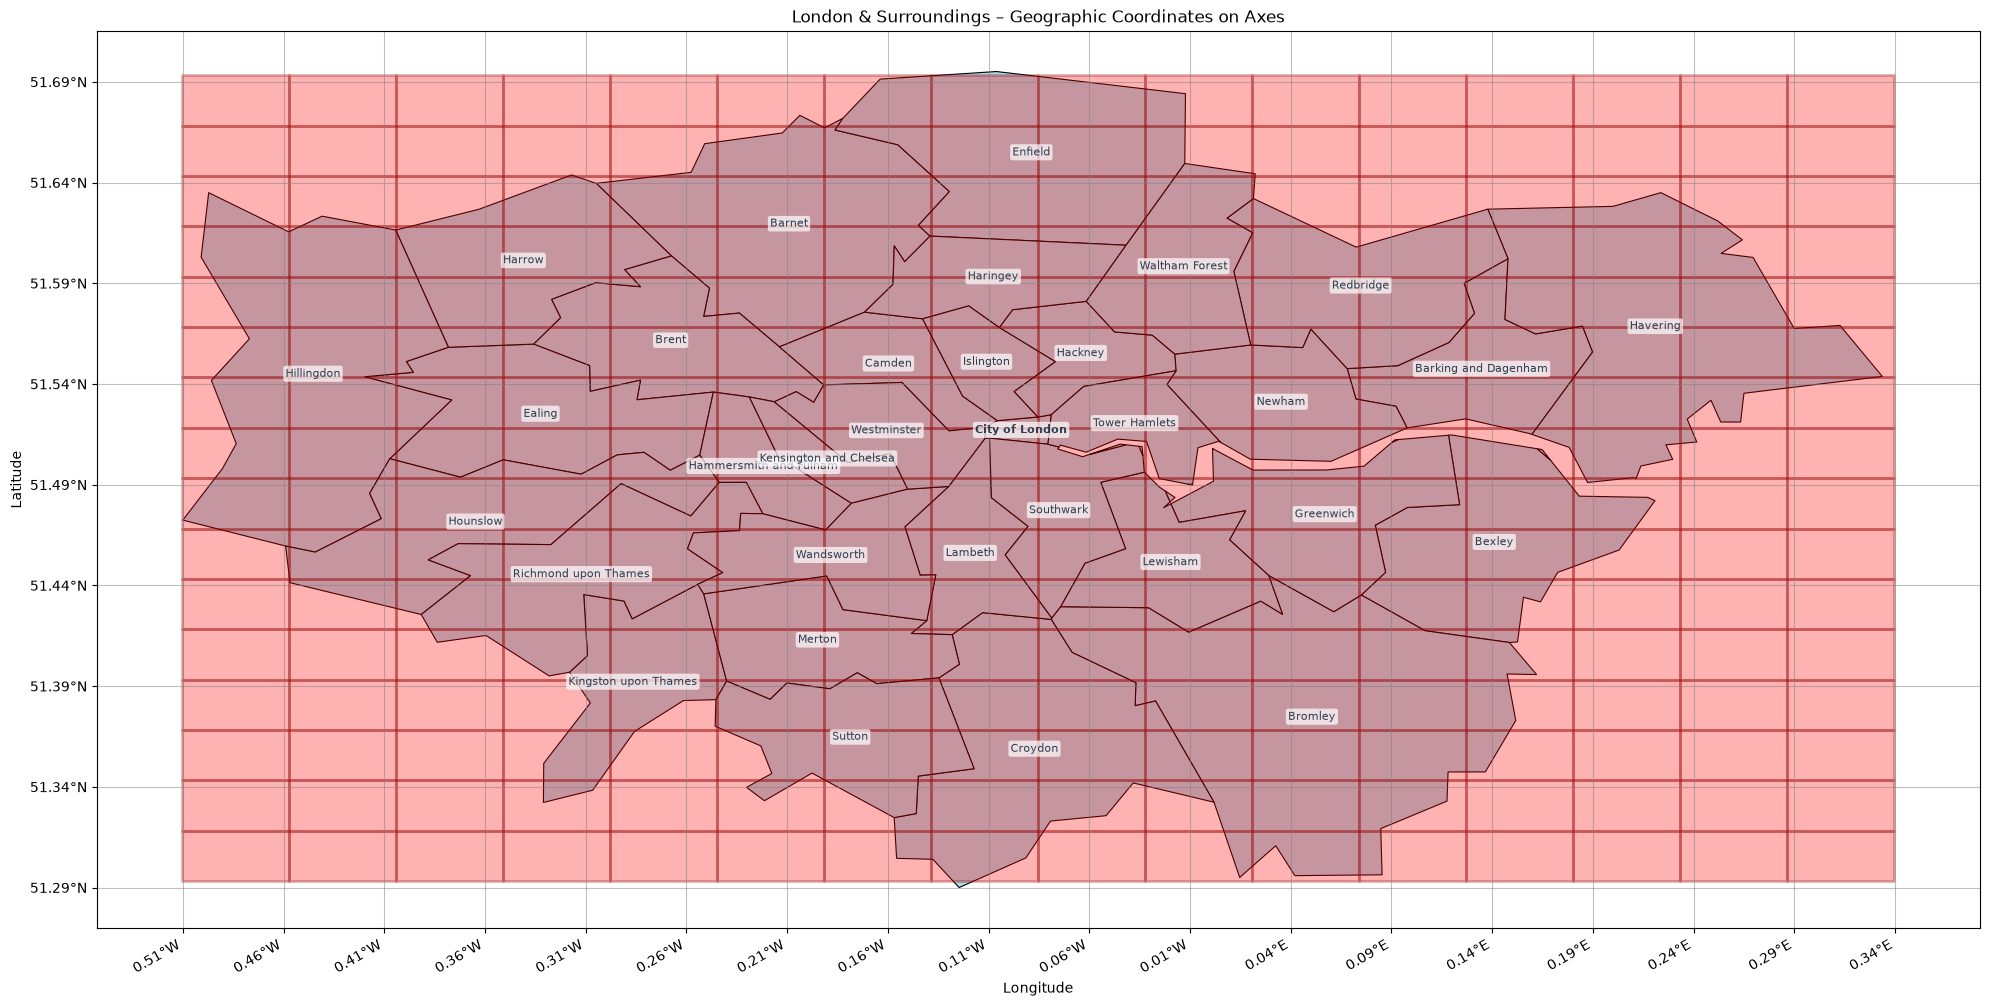

: 

In [ ]:
# Format the labels with degree symbols and direction (E/W, N/S)
def format_lon(lon):
    return f'{abs(lon):.2f}°W' if lon < 0 else f'{lon:.2f}°E'

def format_lat(lat):
    return f'{lat:.2f}°S' if lat < 0 else f'{lat:.2f}°N' 

uk_bfc = gpd.read_file(r"C:\Users\Michał\Downloads\Counties_and_Unitary_Authorities_December_2021_EN_BUC_2462994983727268841\CTYUA_DEC_2021_EN_BUC.shp")
uk_bfc = uk_bfc.to_crs(epsg=4326)
name_col = 'CTYUA21NM'

# Find London (case-insensitive, catches "Greater London", "Inner London", etc.)
london_mask = uk_bfc[name_col].str.contains('London', case=False, na=False)
london = uk_bfc[london_mask]

# Combine all of london shapes 
london_geom = london.geometry.union_all()

# Buffer in degrees
buffer_distance = 0.3
london_buffer = london_geom.buffer(buffer_distance)

# Select all polygons that intersect this buffer and remove what's not needed
surrounding = uk_bfc[uk_bfc.intersects(london_buffer)]
ix = surrounding[name_col].isin(['Hertfordshire', 'Essex', 'Kent', 'Surrey', 'Thurrock'])
surrounding = surrounding[~ix]

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 20))

# Plot all of UK faintly in grey for context
#uk_bfc.plot(ax=ax, color='lightgrey', edgecolor='none', alpha=0.5)

# Plot the main data
surrounding.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.8)

# --- Add Grid ---
ax.grid(True, which='major', linestyle='-', linewidth=0.8, color='grey', alpha=0.5)
ax.grid(True, which='minor', linestyle='--', linewidth=0.5, color='lightgrey', alpha=0.3)

# --- Add Labels for ALL areas (centroids) ---
for idx, row in surrounding.iterrows():
    # Get the centroid of the polygon
    centroid = row.geometry.centroid
    # Get the name 
    label = row[name_col]
    
    # Adjust font size based on the area size (optional)
    # Larger areas = bigger labels
    area = row.geometry.area
    fontsize = 8 if area < 1e8 else 10  # tweak based on your data scale
    
    # Plot the label
    ax.text(centroid.x, centroid.y, label, 
            fontsize=fontsize, 
            ha='center', va='center', 
            fontweight='bold' if 'London' in str(label) else 'normal',
            color='#2C3E50',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

# --- Set tick intervals based on your data extent ---
# Get the bounds (xmin, ymin, xmax, ymax) in the map's CRS (EPSG:27700)
bounds = surrounding.total_bounds  # returns (minx, miny, maxx, maxy)

# Calculate tick spacing
x_range = bounds[2] - bounds[0]
y_range = bounds[3] - bounds[1]
tick_spacing = 0.05

# Create tick positions
x_ticks = np.arange(bounds[0], bounds[2] + tick_spacing, tick_spacing)
y_ticks = np.arange(bounds[1], bounds[3] + tick_spacing, tick_spacing)
ax.set_xticks(x_ticks)
ax.tick_params(axis='x', rotation=30, rotation_mode='xtick')
ax.set_yticks(y_ticks)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format_lon(x)))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format_lat(x)))

# --- Axis labels ---
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('London & Surroundings – Geographic Coordinates on Axes')

polygon_latlon = Polygon([
    (-0.51, 51.29),  # lon, lat
    (-0.51, 51.69),
    (0.34, 51.69),
    (0.34, 51.29)
])

# --- 3. Convert to a GeoDataFrame with CRS EPSG:4326 (WGS84) ---
gdf_poly = gpd.GeoDataFrame(
    {'geometry': [polygon_latlon]},
    crs='EPSG:4326'
)

    # --- 5. Plot your map and overlay the custom polygon ---
#fig, ax = plt.subplots(figsize=(12, 14))

#gdf_poxly.plot(
grid_box.plot(
    ax=ax,
    color='red',
    alpha=0.3,          # semi-transparent fill
    edgecolor='darkred',
    linewidth=2,
    label='Custom Polygon'
)

plt.tight_layout()
plt.show()
